# MNPBEM Python Tutorial

End-to-end walkthrough of the most common workflow: build a particle, build a BEM solver, sweep an excitation, plot the spectrum.

We use a 20 nm gold sphere in vacuum and the retarded BEM solver (full Maxwell). Total runtime is about 30 seconds on a modern laptop.

## 1. Imports

Every public symbol lives under `mnpbem.<submodule>`. The five submodules you almost always need:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mnpbem.materials import EpsConst, EpsTable
from mnpbem.geometry import trisphere, ComParticle
from mnpbem.bem import BEMRet
from mnpbem.simulation import PlaneWaveRet

## 2. Materials

`EpsTable` reads tabulated `eps(lambda)` from a `.dat` file. The package ships a few common metals:

- `gold.dat`, `silver.dat` (Johnson & Christy)
- `goldpalik.dat`, `silverpalik.dat`, `copperpalik.dat` (Palik)

In [2]:
vacuum = EpsConst(1.0)
gold   = EpsTable('gold.dat')

# Evaluate at a single wavelength: returns (eps, k_vacuum)
eps550, k550 = gold(550.0)
print('eps(550 nm) =', eps550)
print('k(550 nm)   =', k550)

eps(550 nm) = (-5.936768468221724+2.0977419544244365j)
k(550 nm)   = (0.004844882322480889+0.028253561023931662j)


## 3. Geometry

`trisphere(n, diameter)` returns a triangulated unit sphere (n is one of the precomputed mesh sizes: 144, 169, 256, 484, 1024, ...). `ComParticle` glues the triangulated surface to its surrounding dielectric environment.

In [3]:
diameter = 20.0
sphere   = trisphere(144, diameter)

# inout=[[2, 1]] means: outside dielectric is eps[1] (= gold), 
# inside is eps[0] (= vacuum). The trailing 1 marks the closed surface.
# `interp='curv'` enables curvature-corrected quadrature (recommended).
epstab = [vacuum, gold]
p      = ComParticle(epstab, [sphere], [[2, 1]], 1, interp='curv')

print('faces  :', p.nfaces)
print('verts  :', p.nverts)

faces  : 284
verts  : 144


## 4. Build solver and excitation

In [4]:
bem = BEMRet(p)

# x-polarized plane wave propagating along +z
exc = PlaneWaveRet(np.array([[1.0, 0.0, 0.0]]),
                   np.array([[0.0, 0.0, 1.0]]))

## 5. Wavelength sweep

Pattern: build the excitation potential, hand it to the solver, read off the cross sections.

In [5]:
enei = np.linspace(400.0, 800.0, 5)
ext  = np.zeros_like(enei)
sca  = np.zeros_like(enei)

for i, e in enumerate(enei):
    sig, bem = bem.solve(exc.potential(p, e))
    ext[i] = float(np.real(np.ravel(exc.extinction(sig))[0]))
    sca_val = exc.scattering(sig)
    sca[i]  = float(np.real(
        np.ravel(sca_val[0] if isinstance(sca_val, tuple) else sca_val)[0]))

abs_ = ext - sca
print('peak: lambda = {:.0f} nm, ext = {:.2f} nm^2'.format(
    enei[np.argmax(ext)], ext.max()))
print('(For a smoother curve, increase the wavelength count to 21 or 41 — about 2-4x slower.)')

peak: lambda = 500 nm, ext = 133.25 nm^2
(For a smoother curve, increase the wavelength count to 21 or 41 — about 2-4x slower.)


## 6. Plot the spectrum

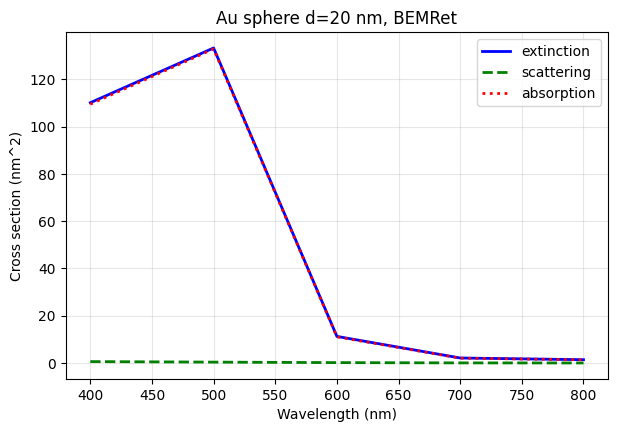

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(enei, ext,  'b-',  lw=2, label='extinction')
ax.plot(enei, sca,  'g--', lw=2, label='scattering')
ax.plot(enei, abs_, 'r:',  lw=2, label='absorption')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Cross section (nm^2)')
ax.set_title('Au sphere d=20 nm, BEMRet')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 7. Where to next

- See `examples/02_dimer_gold.py` for a two-particle dimer.
- See `examples/03_substrate_layered.py` for a sphere on a glass substrate (`BEMRetLayer`).
- See `examples/04_dipole_decay.py` for dipole quenching above a sphere.
- See `examples/05_eels.py` for EELS spectra.
- See `examples/06_iterative_aca.py` for the iterative `BEMRetIter` solver.
- See `examples/07_gpu_multigpu.py` for GPU and multi-GPU dispatch.
- For a MATLAB-to-Python migration cheat sheet, see `docs/MIGRATION_GUIDE.md`.
- The full public API is documented in `docs/API_REFERENCE.md`.